In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap
from remo3d import Model

# Initial model

51 simulation tasks prepared
Progress: [==================================================] 100% 
Processed in:  0:00:03.397967


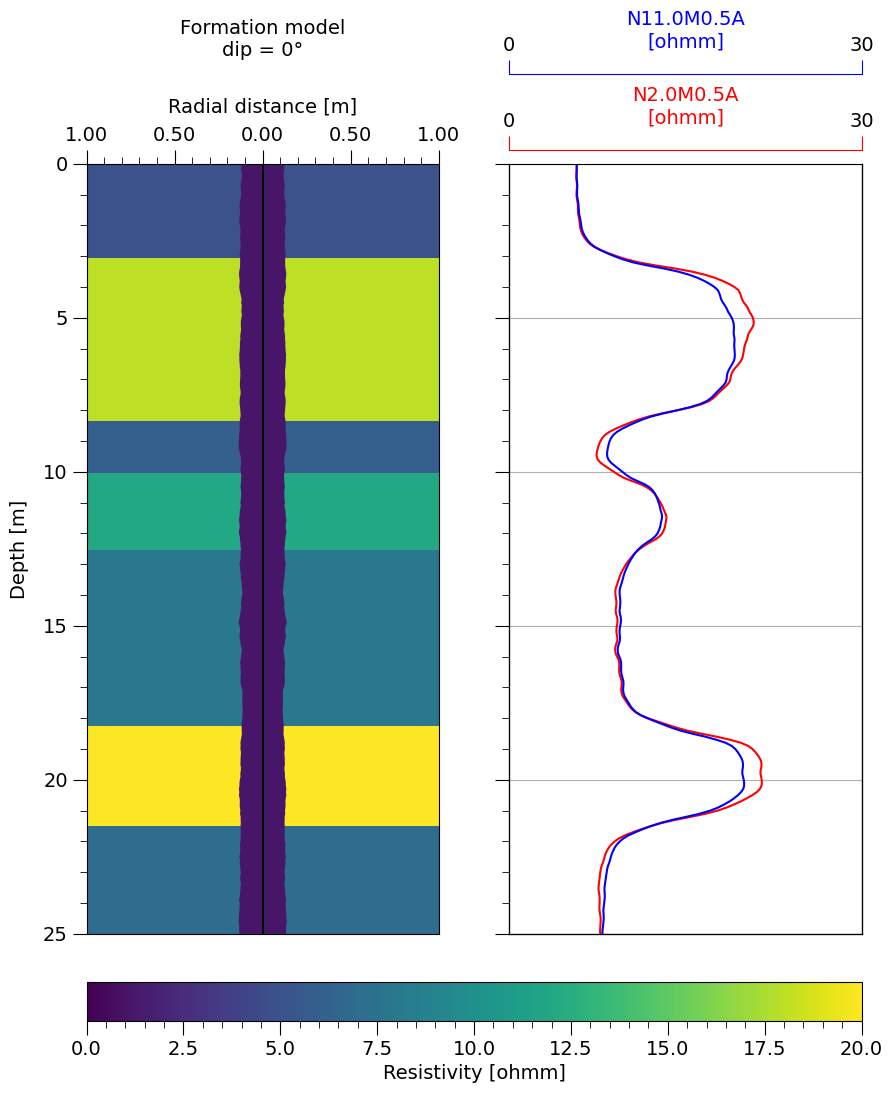

In [7]:
# Specify input data
#all_tools = ["B5.7A0.4M", "B4.48A1.62M", "M1.0A0.1B", "A2.0M0.5N", "N0.5M2.0A", "M4.0A0.5B"] # logging tools
# all_tools = ['N2.0M0.5A', 'N11.0M0.5A']
all_tools = ["B5.7A0.4M", "B4.48A1.62M", "M1.0A0.1B", "A2.0M0.5N", "N0.5M2.0A", "M4.0A0.5B", 'N2.0M0.5A', 'N11.0M0.5A']
#formation_model_file = "./Input/Ex1/Formation.txt" # path to file with formation parameters
formation_model_file = np.loadtxt("./Input/Ex1/Formation.txt", skiprows=2)
formation_model_file[:, 2:4] = np.nan
borehole_model_file = "./Input/Ex1/Borehole.txt" # path to file with borehole parameters
measurement_depths = np.arange(0, 25.1, 0.1) # measurement points

# Create model and simulate logs
model = Model.compute_synthetic_logs(all_tools, measurement_depths, formation_model_file, borehole_model_file, borehole_geometry_type='diameter', dip=0,
                                     cpu_workers=20, gpu_workers=0, domain_radius=50, batch_size=5, mesh_generator='auto')
# Save results
model.save_results(
    # output_folder=None,
    output_folder="./Output",
    #plot_layout=[["B5.7A0.4M", "B4.48A1.62M"], ["M1.0A0.1B", "A2.0M0.5N", "N0.5M2.0A", "M4.0A0.5B"]],
    plot_layout=[all_tools],
    plot_depth_lim=[0, 25], plot_aspect_ratio=1.25,
    model_rad_lim=[-1, 1], model_res_lim=[0, 20],
    logs_colours = [["red", "blue"], ["green", "orange", "purple", "deepskyblue"]],
    logs_res_lim=[0, 30], logs_at_nan="break"
)
